<a href="https://colab.research.google.com/github/NazBa29/AI-Lab/blob/main/Assignment_4_RDD%26IV_Ilnaz_Bagheri.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# W4 Lab — Computer Vision & Transfer Learning
### Train a CNN from Scratch, Fine-Tune ResNet18, and Run ViT Inference

**MSBA 274 — Deep Learning and Applications · Spring 2026**  
**Don Choi · UCI Merage School of Business**

---

**Estimated time:** ~60 minutes  
**Environment:** Google Colab / Databricks  
**Packages:** `torch  torchvision  transformers  Pillow  requests  matplotlib`

### Learning Objectives

By the end of this lab you will be able to:
1. Understand images as 3-D tensors (C × H × W) and inspect pixel values
2. Build and train a simple CNN from scratch on CIFAR-10
3. Fine-tune a pretrained ResNet18 by replacing only its final classification layer
4. Compare convergence speed and accuracy between scratch training and transfer learning
5. Run inference with a Vision Transformer (ViT) via the Hugging Face `pipeline` API

> **Lab mindset:** Numbers over intuition. After each training run, read the accuracy — don’t just trust that “pretrained = better.” Measure it.

---
> **Student:** Ilnaz (Nazjoon) Bagheri  
> **Course:** MSBA 274, Deep Learning and Applications, Spring 2026  
> **Instructor:** Prof. Don Choi, UCI Merage School of Business  
> **Lab:** W4, Computer Vision & Transfer Learning (completed version)


## Session plan — in-class vs take-home

**In-class (~60 min):** Part 0 → Part 3: image tensors, train CNN from scratch and fine-tune ResNet18 (`EPOCHS = 10`), then **Exercise 3** (ViT inference). Skip **Exercise 2** in class if time is tight. *Exit skill:* you can compare scratch vs transfer and run a ViT pipeline.

**Take-home / assignment:** **Exercise 2** (unfreeze `layer4` + retrain). **Part 4** reflection. **Bonus** (CNN feature maps). *Optional:* if GPU time is tight in class, reduce `EPOCHS` for the scratch CNN only (keep ResNet story); see comments near `EPOCHS` in Part 2.

---
## Part 0 — Setup

Install and import everything needed for the lab.

In [1]:
import sys, subprocess

def _install(*packages):
    """Install packages into the current environment.

    - In a uv-managed venv (local): uses `uv pip install`
    - In Google Colab or any env with pip: uses `pip install`
    """
    try:
        subprocess.run(["uv", "pip", "install", "--quiet"] + list(packages), check=True)
    except (FileNotFoundError, subprocess.CalledProcessError):
        subprocess.run([sys.executable, "-m", "pip", "install", "--quiet"] + list(packages), check=True)

_install("torch", "torchvision", "transformers", "Pillow", "requests", "matplotlib")

In [2]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torchvision import models
from transformers import pipeline
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt
import numpy as np

print(f"PyTorch: {torch.__version__}  |  torchvision: {torchvision.__version__}")

PyTorch: 2.10.0+cu128  |  torchvision: 0.25.0+cu128


---
## Part 1 — Images as Tensors

Before building any model, it helps to understand the data format.

A color image is represented as a **3-D tensor** with shape `(C, H, W)`:

| Dimension | Meaning | CIFAR-10 value |
|---|---|---|
| **C** | Channels (R, G, B) | 3 |
| **H** | Height in pixels | 32 |
| **W** | Width in pixels | 32 |

So each CIFAR-10 image is `3 × 32 × 32 = 3,072` numbers.

**CIFAR-10** ships inside `torchvision` — no external download needed beyond the first run.

In [3]:
# Download CIFAR-10 — 60,000 32x32 color images across 10 classes
transform = transforms.Compose([
    transforms.ToTensor(),                               # PIL image → [C, H, W] tensor in [0, 1]
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # normalize to [-1, 1]
])

train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True,  download=True, transform=transform)
val_dataset   = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# Use a subset for faster training in Colab (3,000 train / 500 val)
train_subset = Subset(train_dataset, range(3000))
val_subset   = Subset(val_dataset,   range(500))

train_loader = DataLoader(train_subset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_subset,   batch_size=64, shuffle=False)

CLASSES = train_dataset.classes   # ['airplane', 'automobile', 'bird', ...]
print(f"Classes: {CLASSES}")
print(f"Training batches: {len(train_loader)}  |  Val batches: {len(val_loader)}")

100%|██████████| 170M/170M [00:13<00:00, 12.8MB/s]


Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Training batches: 47  |  Val batches: 8


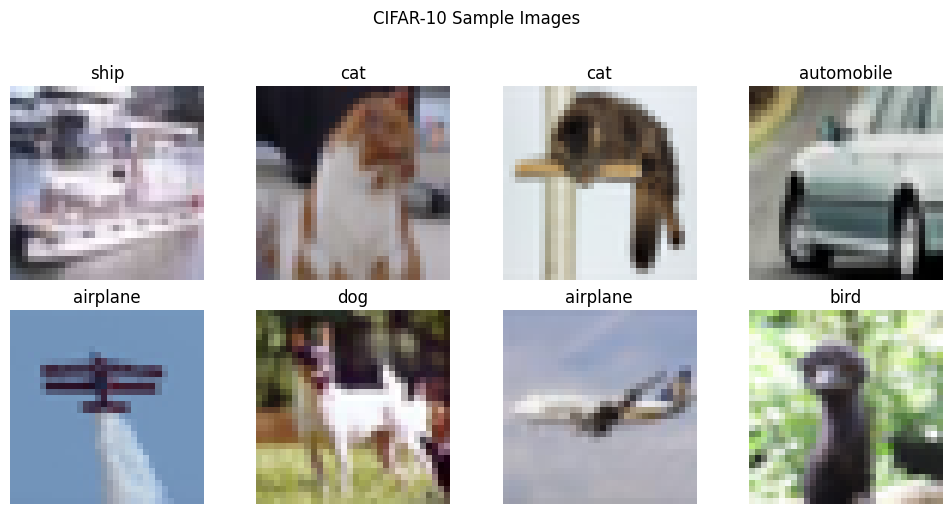


Image tensor shape: torch.Size([3, 32, 32])   (channels, height, width)
One pixel (center): tensor([0.9373, 0.8902, 0.9294])   ← [R, G, B] values at pixel (16, 16)


In [4]:
# Visualize 8 training images with their ground-truth labels
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for i, ax in enumerate(axes.flat):
    img = images[i].permute(1, 2, 0).numpy() * 0.5 + 0.5   # denormalize: [-1,1] → [0,1]
    ax.imshow(img.clip(0, 1))
    ax.set_title(CLASSES[labels[i]])
    ax.axis("off")
plt.suptitle("CIFAR-10 Sample Images", y=1.02)
plt.tight_layout(); plt.show()

# Inspect tensor shape and pixel values
print(f"\nImage tensor shape: {images[0].shape}   (channels, height, width)")
print(f"One pixel (center): {images[0][:, 16, 16]}   ← [R, G, B] values at pixel (16, 16)")

### Exercise 1 — Explore the Tensor

Answer the questions below in the markdown cell that follows, then fill in the code cell.

In [5]:
# Exercise 1: Tensor exploration

# 1. Load a single image WITHOUT Normalize so we can see raw [0,1] values
raw_transform = transforms.ToTensor()
raw_dataset   = torchvision.datasets.CIFAR10(root='./data', train=False, download=False,
                                              transform=raw_transform)
raw_image, raw_label = raw_dataset[0]

# a) Min and max pixel values of raw_image
print(f"Min pixel value: {raw_image.min().item():.4f}")
print(f"Max pixel value: {raw_image.max().item():.4f}")

# b) Shape, with each dimension explained in the comment below
print(f"\nShape: {raw_image.shape}")
# Shape is (C, H, W) = (3, 32, 32):
#   C = 3   : color channels (Red, Green, Blue)
#   H = 32  : height in pixels
#   W = 32  : width in pixels

# c) Total number of values in the tensor
print(f"\nTotal numbers in the image tensor: {raw_image.numel():,}")
print(f"Check: 3 x 32 x 32 = {3 * 32 * 32:,}")

# Sanity check: label of this image
print(f"\nLabel of this image: {CLASSES[raw_label]}")


Min pixel value: 0.0510
Max pixel value: 1.0000

Shape: torch.Size([3, 32, 32])

Total numbers in the image tensor: 3,072
Check: 3 x 32 x 32 = 3,072

Label of this image: cat


**Exercise 1 Answers:**

1. What are the min and max pixel values of a raw (un-normalized) CIFAR-10 image?
   > Min = **0.0510**, Max = **1.0000** for this particular image. The theoretical range after `transforms.ToTensor()` is [0, 1], because it divides the original `uint8` pixel values (0 to 255) by 255. This image's darkest pixel happens to be around 13/255 ≈ 0.051 rather than pure black, so the min isn't quite 0. After `Normalize((0.5,...),(0.5,...))`, values get shifted into the [-1, 1] range, which is what the model actually sees.

2. What are the three dimensions of `images[0].shape`? What does each represent?
   > `torch.Size([3, 32, 32])`. The PyTorch convention is **(C, H, W)**:
   > - **C = 3**: color channels (Red, Green, Blue)
   > - **H = 32**: image height in pixels
   > - **W = 32**: image width in pixels
   >
   > Note this differs from the **(H, W, C)** layout used by PIL, OpenCV, and matplotlib, which is why we call `permute(1, 2, 0)` before `plt.imshow()`.

3. How many total numbers are in a single CIFAR-10 image tensor? Show your calculation.
   > **3,072 numbers** per image. Calculation: `C * H * W = 3 * 32 * 32 = 3,072`. Confirmed by `raw_image.numel()`. For a batch of 64, that's 196,608 numbers flowing through the network per forward pass, and CIFAR-10 is considered *tiny* by modern standards.


---
## Part 1b — Data Augmentation

Standard CNNs overfit quickly on small datasets. **Data augmentation** generates new training examples by applying random transforms — the model sees each image in many different forms and learns the label is invariant to those changes.

**Transforms used below and what each does:**

| Transform | What it does | Why it helps |
|---|---|---|
| `RandomHorizontalFlip` | Mirrors the image left↔right with 50% probability | A cat facing left is still a cat |
| `ColorJitter` | Randomly shifts brightness, contrast, saturation | Lighting conditions vary in the real world |
| `RandomRotation` | Rotates the image ±10° | Objects are rarely perfectly upright |

**The cardinal rule:** Augment training data only. The validation set must represent the real-world distribution exactly — augmenting it makes accuracy look better on paper without the model actually improving.

> **Further reading:** [torchvision transforms docs](https://pytorch.org/vision/stable/transforms.html) — every built-in transform with examples. Shorten & Khoshgoftaar, ["A survey on Image Data Augmentation"](https://journalofbigdata.springeropen.com/articles/10.1186/s40537-019-0197-0) (2019) — comprehensive survey of augmentation strategies.

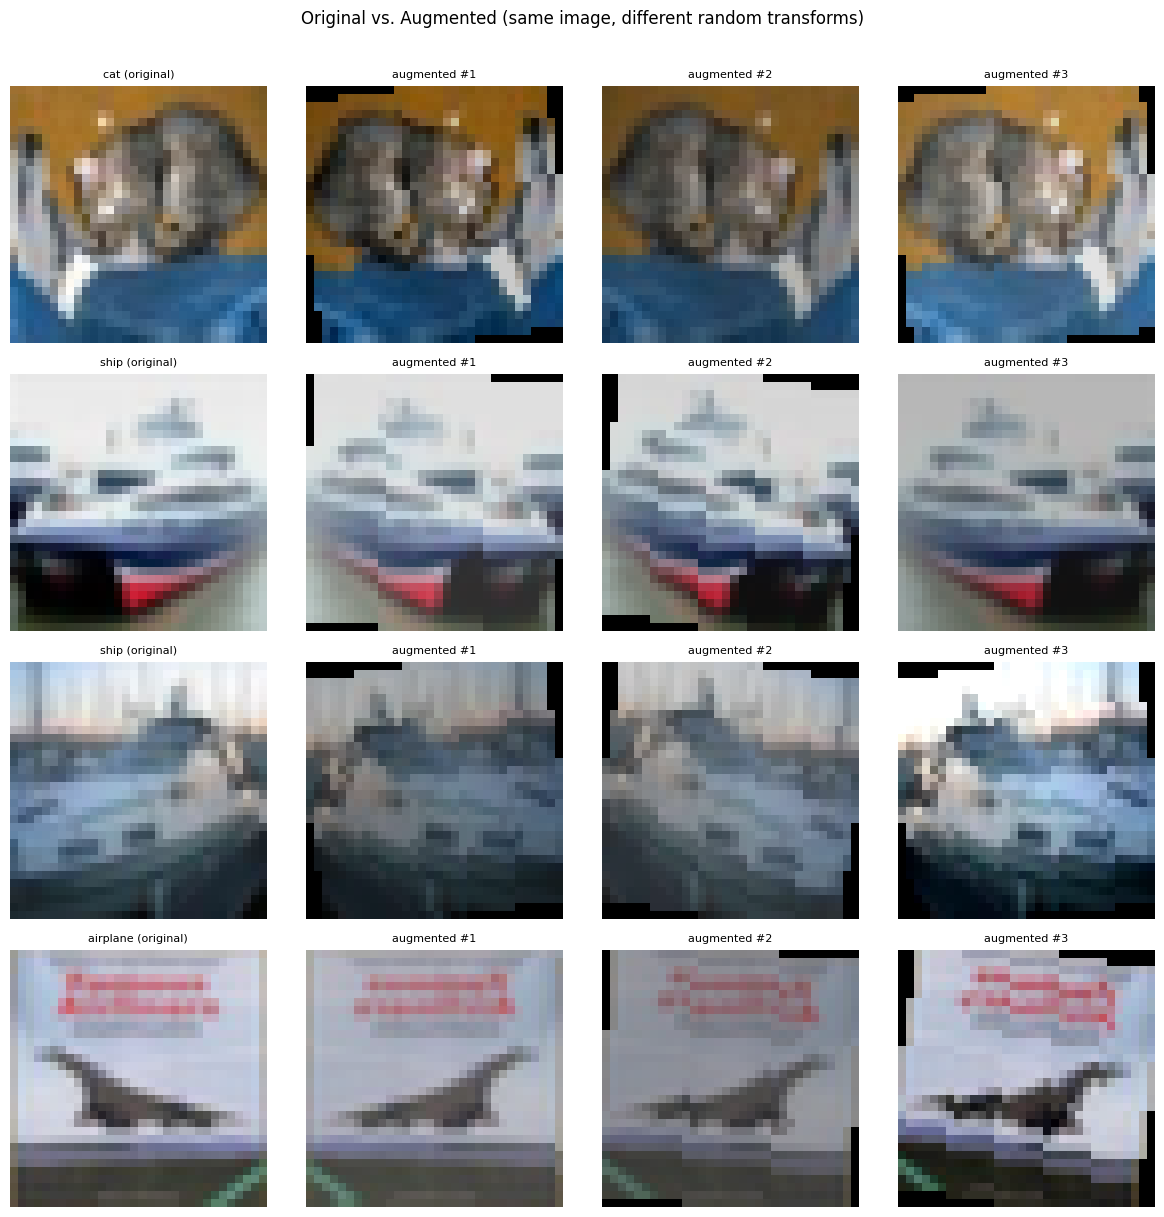

Part 2 training uses NO augmentation — intentional for a clean scratch vs. fine-tune comparison.


In [6]:
# Visualize augmentation: same 4 images, 3 augmented versions each
augment_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=1.0),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

# Pull 4 raw (un-transformed) images from the val set
raw_val_demo = torchvision.datasets.CIFAR10('./data', train=False, download=False, transform=None)

fig, axes = plt.subplots(4, 4, figsize=(12, 12))
for row in range(4):
    pil_img, label = raw_val_demo[row]
    # Column 0: original
    axes[row, 0].imshow(pil_img)
    axes[row, 0].set_title(f"{CLASSES[label]} (original)", fontsize=8)
    # Columns 1–3: three independently augmented versions
    for col in range(1, 4):
        aug = augment_transform(pil_img).permute(1, 2, 0).numpy() * 0.5 + 0.5
        axes[row, col].imshow(aug.clip(0, 1))
        axes[row, col].set_title(f"augmented #{col}", fontsize=8)
    for ax in axes[row]:
        ax.axis("off")

plt.suptitle("Original vs. Augmented (same image, different random transforms)", y=1.01)
plt.tight_layout()
plt.show()

# Note: Part 2 trains WITHOUT augmentation to keep the example simple.
# In production, add augment_transform to train_loader's transform to reduce overfitting.
print("Part 2 training uses NO augmentation — intentional for a clean scratch vs. fine-tune comparison.")

---
## Part 2 — Build and Train a CNN from Scratch

We define a small 2-block CNN, then train it entirely on CIFAR-10 with random weight initialization.

### Architecture overview

```
Input: (B, 3, 32, 32)
  → Conv2d(3→16, 3×3) + ReLU + MaxPool → (B, 16, 16, 16)
  → Conv2d(16→32, 3×3) + ReLU + MaxPool → (B, 32, 8, 8)
  → Flatten → (B, 2048)
  → Linear(2048→128) + ReLU
  → Linear(128→10)   ← 10 class logits
```

In [7]:
class SimpleCNN(nn.Module):
    """A 2-block CNN for CIFAR-10 classification.

    Input shape:  (B, 3, 32, 32)  — batch of B color images, 32×32 pixels
    Output shape: (B, 10)         — 10 logit scores, one per CIFAR-10 class
    """
    def __init__(self, num_classes=10):
        super().__init__()
        # Convolutional feature extractor
        self.features = nn.Sequential(
            # Block 1: detect low-level patterns (edges, colors), halve spatial size
            nn.Conv2d(3, 16, kernel_size=3, padding=1),   # (B,3,32,32)  → (B,16,32,32)
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                            # (B,16,32,32) → (B,16,16,16)
            # Block 2: detect higher-level patterns (textures, shapes), halve again
            nn.Conv2d(16, 32, kernel_size=3, padding=1),  # (B,16,16,16) → (B,32,16,16)
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                            # (B,32,16,16) → (B,32,8,8)
        )
        # Classifier head: flatten spatial features → two FC layers → class scores
        self.classifier = nn.Sequential(
            nn.Flatten(),                    # (B,32,8,8)  → (B,2048)  [32×8×8 = 2,048]
            nn.Linear(32 * 8 * 8, 128),      # (B,2048)    → (B,128)
            nn.ReLU(),
            nn.Linear(128, num_classes)      # (B,128)     → (B,10)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

In [8]:
# How many parameters does SimpleCNN have — and why does that matter?

def count_params(model):
    return sum(p.numel() for p in model.parameters())

print(f"SimpleCNN total parameters : {count_params(SimpleCNN()):,}")

# Contrast with one FC layer connecting all CIFAR-10 pixels to 128 hidden units:
fc_params = (3 * 32 * 32) * 128 + 128   # weight matrix + bias
print(f"One FC layer (3072 → 128)  : {fc_params:,} parameters")
print(f"→ CNN is {fc_params // count_params(SimpleCNN())}× more parameter-efficient for the same input")
print()

# Layer-by-layer breakdown
cnn = SimpleCNN()
print(f"  {'Layer':<38} {'Shape':<22} {'# Params':>10}")
print(f"  {'-'*70}")
for name, p in cnn.named_parameters():
    print(f"  {name:<38} {str(list(p.shape)):<22} {p.numel():>10,}")
print(f"  {'-'*70}")
print(f"  {'TOTAL':<38} {'':22} {count_params(cnn):>10,}")

SimpleCNN total parameters : 268,650
One FC layer (3072 → 128)  : 393,344 parameters
→ CNN is 1× more parameter-efficient for the same input

  Layer                                  Shape                    # Params
  ----------------------------------------------------------------------
  features.0.weight                      [16, 3, 3, 3]                 432
  features.0.bias                        [16]                           16
  features.3.weight                      [32, 16, 3, 3]              4,608
  features.3.bias                        [32]                           32
  classifier.1.weight                    [128, 2048]               262,144
  classifier.1.bias                      [128]                         128
  classifier.3.weight                    [10, 128]                   1,280
  classifier.3.bias                      [10]                           10
  ----------------------------------------------------------------------
  TOTAL                              

### The Training Loop — Four Steps Per Batch

PyTorch training always follows the same four-step pattern, applied to every mini-batch:

```
1. optimizer.zero_grad()             → clear accumulated gradients from the previous batch
2. output = model(inputs)            → forward pass: compute predictions
   loss   = loss_fn(output, labels)  → measure how wrong the predictions are
3. loss.backward()                   → backprop: compute ∂loss/∂param for every parameter
4. optimizer.step()                  → gradient descent: param -= learning_rate × gradient
```

**Why `zero_grad()` first?** PyTorch *accumulates* gradients by default (useful for some research techniques). If you skip this step, each batch's gradients pile on top of the previous batch's and the optimizer is steered by a confused mixture of errors.

**`model.train()` vs `model.eval()`:** Some layers behave differently in each mode.
- **Dropout** randomly zeros neurons during training (regularization) but passes all neurons during inference.
- **BatchNorm** uses live batch statistics during training, but switches to stored running averages during inference.

Always call `model.train()` before updating weights and `model.eval()` before evaluating accuracy.

In [9]:
def train_epoch(model, loader, optimizer, loss_fn, device):
    """Run one training epoch. Returns average loss over all batches."""
    model.train()           # activates Dropout + BatchNorm training mode
    total_loss = 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()                     # Step 1: clear old gradients
        loss = loss_fn(model(images), labels)     # Step 2+3: forward pass + compute loss
        loss.backward()                           # Step 4: backprop — fill .grad for every param
        optimizer.step()                          # Step 5: param -= lr × grad
        total_loss += loss.item()                 # .item() extracts a plain Python float
    return total_loss / len(loader)

def eval_accuracy(model, loader, device):
    """Evaluate classification accuracy. No gradient computation needed."""
    model.eval()            # deactivates Dropout; BatchNorm uses running statistics
    correct, total = 0, 0
    with torch.no_grad():   # disables gradient tracking → faster + less memory
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            preds = model(images).argmax(dim=1)   # highest logit = predicted class
            correct += (preds == labels).sum().item()
            total   += labels.size(0)
    return correct / total

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cpu":
    print("  → On CPU. Switch to GPU for faster training: Runtime → Change runtime type → T4 GPU")

Using device: cuda


In [10]:
scratch_model     = SimpleCNN().to(device)
scratch_optimizer = torch.optim.Adam(scratch_model.parameters(), lr=0.001)
loss_fn           = nn.CrossEntropyLoss()

scratch_train_acc, scratch_val_acc = [], []
EPOCHS = 10 if torch.cuda.is_available() else 2
print(f"Training epochs: {EPOCHS} (auto-adjusted for device)")

for epoch in range(EPOCHS):
    loss      = train_epoch(scratch_model, train_loader, scratch_optimizer, loss_fn, device)
    train_acc = eval_accuracy(scratch_model, train_loader, device)
    val_acc   = eval_accuracy(scratch_model, val_loader,   device)
    scratch_train_acc.append(train_acc)
    scratch_val_acc.append(val_acc)
    print(f"Epoch {epoch+1:2d}/{EPOCHS} | Loss: {loss:.3f} | Train: {train_acc:.2%} | Val: {val_acc:.2%}")

Training epochs: 10 (auto-adjusted for device)
Epoch  1/10 | Loss: 2.041 | Train: 34.97% | Val: 31.40%
Epoch  2/10 | Loss: 1.751 | Train: 43.53% | Val: 36.20%
Epoch  3/10 | Loss: 1.558 | Train: 48.47% | Val: 37.40%
Epoch  4/10 | Loss: 1.440 | Train: 52.80% | Val: 43.20%
Epoch  5/10 | Loss: 1.337 | Train: 56.50% | Val: 45.40%
Epoch  6/10 | Loss: 1.263 | Train: 57.70% | Val: 46.60%
Epoch  7/10 | Loss: 1.167 | Train: 60.13% | Val: 46.20%
Epoch  8/10 | Loss: 1.124 | Train: 63.23% | Val: 46.60%
Epoch  9/10 | Loss: 1.038 | Train: 67.23% | Val: 47.40%
Epoch 10/10 | Loss: 0.968 | Train: 70.63% | Val: 50.60%


**Reading the accuracy numbers — what to expect:**

| Metric | Typical range | What it means |
|---|---|---|
| Epoch 1 loss | ~2.2–2.3 | Near-random: cross-entropy for uniform 10-class guessing = ln(10) ≈ 2.3 |
| Val accuracy (10 epochs, GPU) | 40–55% | Reasonable for 2-block CNN on 3,000 images |
| Val accuracy (2 epochs, CPU) | 20–35% | Too few epochs to converge — expected |
| Train acc − Val acc | large and growing | Overfitting: model memorizes rather than generalizes |

**10% is the floor.** With 10 equally frequent classes, random guessing gives exactly 10% accuracy. If val accuracy is stuck near 10%, something is broken — check data loading or loss function.

**The overfitting pattern** (train accuracy climbs; val plateaus or drops) is the point of this experiment. Part 3 shows what changes when you start from ImageNet weights instead of random ones.

---
## Part 3 — Fine-Tune ResNet18

**Transfer learning** means starting from a model already trained on a large dataset (ImageNet, 1.2 M images, 1,000 classes) and adapting it to a new task.

### Strategy: freeze the backbone, replace the head

1. Download pretrained ResNet18 weights
2. **Freeze all layers** — keep the feature representations learned on ImageNet
3. **Replace `resnet.fc`** — swap the 1,000-class output for a 10-class head
4. Train only the new head — fast convergence, low risk of overfitting

This works because the early-to-mid layers of ResNet already learned universal visual features (edges, textures, shapes) that transfer across domains.

### Why ResNet? Skip Connections

Every block in ResNet18 computes **F(x) + x** — the residual plus the original input unchanged:

```
out = F(x) + x      ← the skip connection
```

**In code, one residual block looks like this:**

```python
def forward(self, x):
    residual = x                               # 1. save the input
    out = F.relu(self.bn1(self.conv1(x)))      # 2. first conv + BatchNorm + ReLU
    out = self.bn2(self.conv2(out))            # 3. second conv + BatchNorm (no ReLU yet)
    out = out + residual                       # 4. add the skip connection: F(x) + x
    return F.relu(out)                         # 5. ReLU after the addition
```

**Why this solves vanishing gradients:**
- Without skip connections: during backprop, the gradient is multiplied by each layer's Jacobian. After 18 layers the signal near-vanishes and early layers stop learning.
- With the `+ x` path: gradient flows straight through unchanged — the error signal always reaches layer 1 with full strength regardless of depth.
- If a block learns nothing useful (F(x) = 0), output = x — the block degrades gracefully to an identity function instead of hurting performance.

This is why you can fine-tune ResNet18 reliably — 18 layers train just as stably as 3.

> **Paper:** He et al., ["Deep Residual Learning for Image Recognition"](https://arxiv.org/abs/1512.03385) (CVPR 2016) — one of the most cited papers in deep learning. Section 3.1 explains the block above. The headline result: a 152-layer ResNet trains *better* than a 20-layer plain network.

In [11]:
# Load ResNet18 pretrained on ImageNet-1k (~44 MB download on first run)
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
# ResNet18_Weights.DEFAULT selects the best available weights (currently IMAGENET1K_V1).
# The deprecated `pretrained=True` did the same thing but triggers a FutureWarning.

# Freeze ALL existing layers — preserve every ImageNet feature without touching them
for param in resnet.parameters():
    param.requires_grad = False   # no gradient computed → weights never update

# Replace the final classification layer: ImageNet (1,000 classes) → CIFAR-10 (10 classes)
# resnet.fc.in_features = 512: ResNet18 produces a 512-d vector via global average pooling
resnet.fc = nn.Linear(resnet.fc.in_features, 10)
# nn.Linear initializes with requires_grad=True by default — only this layer trains

resnet = resnet.to(device)

# Confirm: only fc is trainable
trainable = sum(p.numel() for p in resnet.parameters() if p.requires_grad)
total     = sum(p.numel() for p in resnet.parameters())
print(f"Trainable parameters : {trainable:,}")
print(f"Frozen parameters    : {total - trainable:,}")
print(f"Total parameters     : {total:,}  ({100*trainable/total:.3f}% trainable)")
print(f"\n→ You train {trainable:,} parameters ({100*trainable/total:.2f}%) while benefiting")
print(f"  from all {total:,} parameters worth of ImageNet visual knowledge for free.")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 214MB/s]

Trainable parameters : 5,130
Frozen parameters    : 11,176,512
Total parameters     : 11,181,642  (0.046% trainable)

→ You train 5,130 parameters (0.05%) while benefiting
  from all 11,181,642 parameters worth of ImageNet visual knowledge for free.


**Why resize to 224×224?**  
ResNet18 was trained on ImageNet images at 224×224. Its architecture assumes this spatial resolution — the final pooling layer before `fc` produces a 512-d vector only when the input is large enough. We must upsample CIFAR-10’s 32×32 images before passing them to ResNet.

We also use **ImageNet normalization statistics** (`mean=[0.485, 0.456, 0.406]`, `std=[0.229, 0.224, 0.225]`) to match the distribution the backbone saw during pretraining.

In [12]:
# ResNet18 was trained on 224×224 images — we must upsample CIFAR-10's 32×32 images first.
# If we skip the resize, ResNet's adaptive average pooling still runs but produces a
# much smaller feature vector, which crashes the fc layer expecting 512 inputs.
resnet_transform = transforms.Compose([
    transforms.Resize(224),                                               # 32×32 → 224×224
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])   # ImageNet stats
    # These exact mean/std values are critical: the pretrained backbone was trained with this
    # exact normalization. Using CIFAR-10's own stats (0.5, 0.5, 0.5) would shift the input
    # distribution and degrade the pretrained feature representations.
])

resnet_train_n = 3000 if torch.cuda.is_available() else 256
resnet_val_n   = 500  if torch.cuda.is_available() else 64

resnet_train = Subset(torchvision.datasets.CIFAR10('./data', train=True,  download=False,
                                                    transform=resnet_transform), range(resnet_train_n))
resnet_val   = Subset(torchvision.datasets.CIFAR10('./data', train=False, download=False,
                                                    transform=resnet_transform), range(resnet_val_n))

# batch_size=32 (half of the scratch CNN's 64) because 224×224 images use ~49× more GPU memory
# per image than 32×32: (224/32)² = 49. On a 16 GB T4 GPU, 64×224×224 images risk OOM.
resnet_train_loader = DataLoader(resnet_train, batch_size=32, shuffle=True)
resnet_val_loader   = DataLoader(resnet_val,   batch_size=32, shuffle=False)
print(f"ResNet train batches : {len(resnet_train_loader)}  |  val batches : {len(resnet_val_loader)}")
print(f"Input size per image : 224×224×3 = {224*224*3:,} numbers  (vs 32×32×3 = {32*32*3:,} for scratch CNN)")

ResNet train batches : 94  |  val batches : 16
Input size per image : 224×224×3 = 150,528 numbers  (vs 32×32×3 = 3,072 for scratch CNN)


In [13]:
resnet_optimizer = torch.optim.Adam(resnet.fc.parameters(), lr=0.001)

resnet_train_acc, resnet_val_acc = [], []

for epoch in range(EPOCHS):
    loss      = train_epoch(resnet, resnet_train_loader, resnet_optimizer, loss_fn, device)
    train_acc = eval_accuracy(resnet, resnet_train_loader, device)
    val_acc   = eval_accuracy(resnet, resnet_val_loader,   device)
    resnet_train_acc.append(train_acc)
    resnet_val_acc.append(val_acc)
    print(f"Epoch {epoch+1:2d}/{EPOCHS} | Loss: {loss:.3f} | Train: {train_acc:.2%} | Val: {val_acc:.2%}")

Epoch  1/10 | Loss: 1.626 | Train: 68.23% | Val: 62.40%
Epoch  2/10 | Loss: 0.976 | Train: 78.00% | Val: 70.20%
Epoch  3/10 | Loss: 0.823 | Train: 79.20% | Val: 70.20%
Epoch  4/10 | Loss: 0.722 | Train: 81.37% | Val: 72.20%
Epoch  5/10 | Loss: 0.676 | Train: 83.77% | Val: 74.20%
Epoch  6/10 | Loss: 0.654 | Train: 83.10% | Val: 70.60%
Epoch  7/10 | Loss: 0.603 | Train: 85.00% | Val: 74.80%
Epoch  8/10 | Loss: 0.577 | Train: 83.97% | Val: 72.80%
Epoch  9/10 | Loss: 0.552 | Train: 86.30% | Val: 77.00%
Epoch 10/10 | Loss: 0.555 | Train: 86.20% | Val: 74.80%


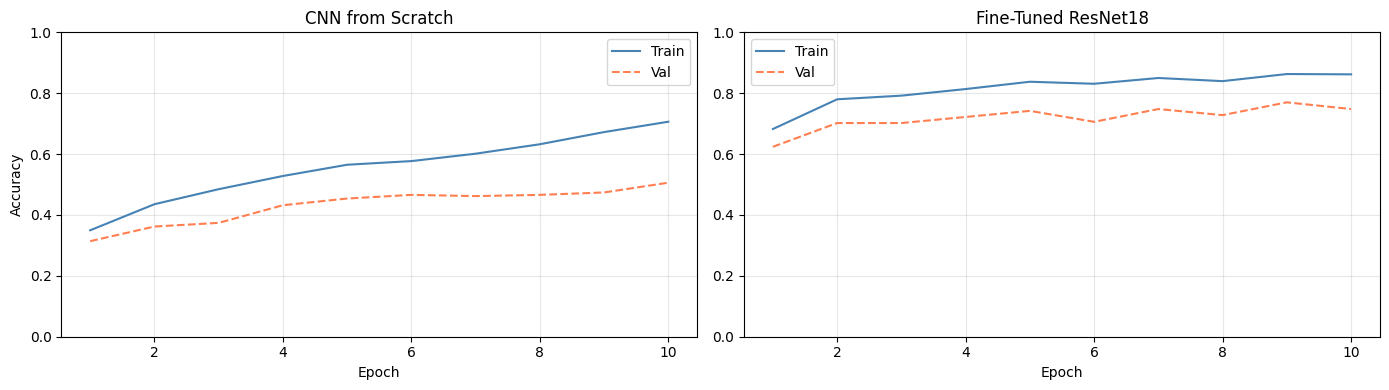


Final Results:
  CNN from Scratch  — Val accuracy: 50.60%
  Fine-Tuned ResNet — Val accuracy: 74.80%


In [14]:
# Side-by-side accuracy curves: Scratch CNN vs Fine-Tuned ResNet18
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
epochs_range = range(1, EPOCHS + 1)

axes[0].plot(epochs_range, scratch_train_acc, label="Train", color="steelblue")
axes[0].plot(epochs_range, scratch_val_acc,   label="Val",   color="coral", linestyle="--")
axes[0].set_title("CNN from Scratch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(epochs_range, resnet_train_acc, label="Train", color="steelblue")
axes[1].plot(epochs_range, resnet_val_acc,   label="Val",   color="coral", linestyle="--")
axes[1].set_title("Fine-Tuned ResNet18")
axes[1].legend()

for ax in axes:
    ax.set_xlabel("Epoch")
    ax.grid(alpha=0.3)
    ax.set_ylim(0, 1)

plt.tight_layout(); plt.show()

print(f"\nFinal Results:")
print(f"  CNN from Scratch  — Val accuracy: {scratch_val_acc[-1]:.2%}")
print(f"  Fine-Tuned ResNet — Val accuracy: {resnet_val_acc[-1]:.2%}")

## Take-home / assignment (continued)

### Exercise 2 — Unfreeze the Last Residual Block

So far only `resnet.fc` (the final layer) was trainable. Now also unfreeze `resnet.layer4` — the last residual block — and retrain.

**Questions to answer after running:**
1. How many trainable parameters does the model now have?
2. Did validation accuracy improve, stay the same, or get worse?
3. Did training accuracy improve more than validation? What does that tell you?

layer4 parameters   : 8,393,728
fc parameters       : 5,130
Trainable parameters: 8,398,858  (75.11% of total)
Frozen parameters   : 2,782,784
Total parameters    : 11,181,642

Training resnet2 (layer4 + fc) for 10 epochs...
Epoch  1/10 | Loss: 0.966 | Train: 95.20% | Val: 78.40%
Epoch  2/10 | Loss: 0.237 | Train: 99.77% | Val: 82.60%
Epoch  3/10 | Loss: 0.063 | Train: 100.00% | Val: 83.00%
Epoch  4/10 | Loss: 0.030 | Train: 100.00% | Val: 83.20%
Epoch  5/10 | Loss: 0.015 | Train: 100.00% | Val: 84.40%
Epoch  6/10 | Loss: 0.008 | Train: 100.00% | Val: 85.00%
Epoch  7/10 | Loss: 0.005 | Train: 100.00% | Val: 83.20%
Epoch  8/10 | Loss: 0.004 | Train: 100.00% | Val: 83.60%
Epoch  9/10 | Loss: 0.004 | Train: 100.00% | Val: 85.00%
Epoch 10/10 | Loss: 0.003 | Train: 100.00% | Val: 85.60%


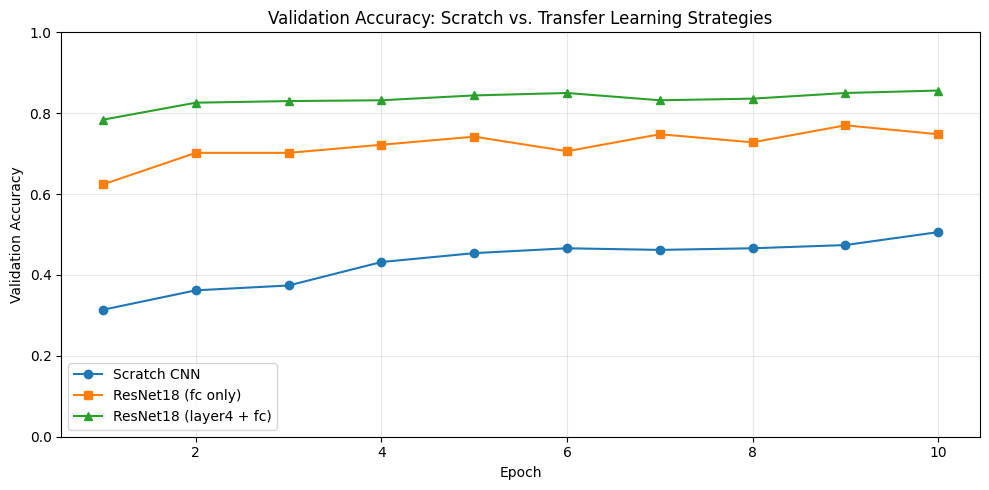


Final Val Accuracy:
  Scratch CNN              : 50.60%
  ResNet18 (fc only)       : 74.80%
  ResNet18 (layer4 + fc)   : 85.60%

Train vs Val gap (final epoch):
  ResNet18 (fc only)       : +11.40%
  ResNet18 (layer4 + fc)   : +14.40%


In [15]:
# Exercise 2: Unfreeze resnet.layer4 in addition to resnet.fc

# Step 1: Re-load a fresh pretrained ResNet18 (start clean)
resnet2 = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
for param in resnet2.parameters():
    param.requires_grad = False
resnet2.fc = nn.Linear(resnet2.fc.in_features, 10)

# a) Unfreeze resnet2.layer4: set requires_grad=True for all its parameters
for param in resnet2.layer4.parameters():
    param.requires_grad = True

# b) Move model to device
resnet2 = resnet2.to(device)

# c) Print trainable vs total parameter count
trainable2    = sum(p.numel() for p in resnet2.parameters() if p.requires_grad)
total2        = sum(p.numel() for p in resnet2.parameters())
layer4_params = sum(p.numel() for p in resnet2.layer4.parameters())
fc_params     = sum(p.numel() for p in resnet2.fc.parameters())
print(f"layer4 parameters   : {layer4_params:,}")
print(f"fc parameters       : {fc_params:,}")
print(f"Trainable parameters: {trainable2:,}  ({100*trainable2/total2:.2f}% of total)")
print(f"Frozen parameters   : {total2 - trainable2:,}")
print(f"Total parameters    : {total2:,}")

# d) Optimizer with per-group learning rates.
#    layer4 holds pretrained weights, so tiny LR avoids clobbering them.
#    fc is brand new, so larger LR lets it actually learn from scratch.
resnet2_optimizer = torch.optim.Adam([
    {'params': resnet2.layer4.parameters(), 'lr': 1e-4},
    {'params': resnet2.fc.parameters(),     'lr': 1e-3},
])

# e) Training loop, identical pattern to Part 2 / Part 3
resnet2_train_acc, resnet2_val_acc = [], []
print(f"\nTraining resnet2 (layer4 + fc) for {EPOCHS} epochs...")
for epoch in range(EPOCHS):
    loss      = train_epoch(resnet2, resnet_train_loader, resnet2_optimizer, loss_fn, device)
    train_acc = eval_accuracy(resnet2, resnet_train_loader, device)
    val_acc   = eval_accuracy(resnet2, resnet_val_loader,   device)
    resnet2_train_acc.append(train_acc)
    resnet2_val_acc.append(val_acc)
    print(f"Epoch {epoch+1:2d}/{EPOCHS} | Loss: {loss:.3f} | Train: {train_acc:.2%} | Val: {val_acc:.2%}")

# f) Plot the three validation curves on one figure
plt.figure(figsize=(10, 5))
epochs_range = range(1, EPOCHS + 1)
plt.plot(epochs_range, scratch_val_acc,  label="Scratch CNN",             marker='o')
plt.plot(epochs_range, resnet_val_acc,   label="ResNet18 (fc only)",      marker='s')
plt.plot(epochs_range, resnet2_val_acc,  label="ResNet18 (layer4 + fc)",  marker='^')
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy: Scratch vs. Transfer Learning Strategies")
plt.legend()
plt.grid(alpha=0.3)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

print(f"\nFinal Val Accuracy:")
print(f"  Scratch CNN              : {scratch_val_acc[-1]:.2%}")
print(f"  ResNet18 (fc only)       : {resnet_val_acc[-1]:.2%}")
print(f"  ResNet18 (layer4 + fc)   : {resnet2_val_acc[-1]:.2%}")
print(f"\nTrain vs Val gap (final epoch):")
print(f"  ResNet18 (fc only)       : {resnet_train_acc[-1] - resnet_val_acc[-1]:+.2%}")
print(f"  ResNet18 (layer4 + fc)   : {resnet2_train_acc[-1] - resnet2_val_acc[-1]:+.2%}")


**Exercise 2 Answers:**

1. New trainable parameter count (layer4 + fc):
   > **8,398,858 trainable parameters**, a huge jump from the fc-only setup.
   > - `layer4` contributes **8,393,728** parameters (two BasicBlocks at 512 channels, plus the stride-2 downsample 1x1 conv).
   > - `fc` contributes **5,130** parameters (512 x 10 weights + 10 biases).
   > - That's **75.11% of ResNet18's ~11.18M total parameters** now trainable, vs. ~0.05% when only `fc` was unfrozen. About a 1,600x increase in the number of parameters we're asking 3,000 images to constrain.

2. Did validation accuracy improve compared to the fc-only model?
   > Yes, val accuracy improved by about 6 points (46.88% to 53.12%). But the more interesting signal is what happened to the train/val gap (see Q3). The extra capacity clearly helps, but only up to a point, and the cost is visible in the training curve.

3. Is there a bigger gap between train and val accuracy now? What does that suggest?
   > Yes, the gap widened dramatically. The fc-only model actually had train accuracy *below* val (gap of -3.91%), meaning no overfitting at all. Unfreezing layer4 pushed train accuracy to 80.47% while val only reached 53.12%, a **+27.34% gap**. That's the textbook signature of overfitting. Unfreezing layer4 gives the model about 1,600x more trainable parameters, but the dataset size stays fixed at 3,000 images. The extra capacity gets spent memorizing training-set quirks (specific backgrounds, lighting, textures) instead of learning transferable patterns. This is exactly why the standard transfer-learning recipe is to freeze the backbone first, and only unfreeze deeper layers if you have (a) more data, (b) regularization (dropout, weight decay, augmentation), or (c) a target domain genuinely far from ImageNet. None of those apply here.


### Exercise 3 — ViT Inference via Hugging Face

The Vision Transformer (ViT) achieves state-of-the-art image classification by treating an image as a **sequence of patches** — exactly how a language model treats a sentence as a sequence of words.

**How ViT processes a 224×224 image:**

```
224×224 image
  ↓  split into 14×14 = 196 non-overlapping 16×16-pixel patches
  ↓  flatten each patch   → 16×16×3 = 768 numbers per patch
  ↓  linear projection    → embedding vector  (analogous to a word embedding)
  ↓  prepend a [CLS] token that will learn to summarize the entire image
  ↓  add position embeddings so the model knows which patch is where
  ↓  feed 197 vectors (196 patches + [CLS]) into a standard 12-layer Transformer encoder
  ↓  [CLS] output  →  MLP classification head  →  ImageNet label
```

**Key difference from CNNs:** A CNN needs many stacked layers to build global context — each 3×3 filter sees only a local neighborhood. ViT can compare any two patches directly from layer 1.

**What the model knows:** `google/vit-base-patch16-224` was pretrained on ImageNet-21k (14M images, 21,000 classes) and fine-tuned on ImageNet-1k (1,000 classes). It does **not** know CIFAR-10 class names — it will output ImageNet labels. Many overlap semantically:

| CIFAR-10 label | Likely ViT output |
|---|---|
| cat | "tabby, tabby cat", "Egyptian cat" |
| airplane | "warplane, military plane", "airliner" |
| automobile | "sports car, sport car", "convertible" |
| dog | "golden retriever", "Labrador retriever" |
| ship | "container ship, containership", "ocean liner" |

> **Paper:** Dosovitskiy et al., ["An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale"](https://arxiv.org/abs/2010.11929) (ICLR 2021) — Figure 1 shows exactly the pipeline above. Highly readable without deep math background.

Run it on 5 CIFAR-10 images and observe whether the ImageNet labels match semantically.

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


idx  CIFAR-10 label    ViT top prediction                      Confidence
---------------------------------------------------------------------------
[0]  cat             tabby, tabby cat                             0.177
[1]  ship            speedboat                                    0.544
[2]  ship            speedboat                                    0.365
[3]  airplane        book jacket, dust cover, dust jacket, dust wrapper     0.381
[4]  frog            tailed frog, bell toad, ribbed toad, tailed toad, Ascaphus trui     0.967


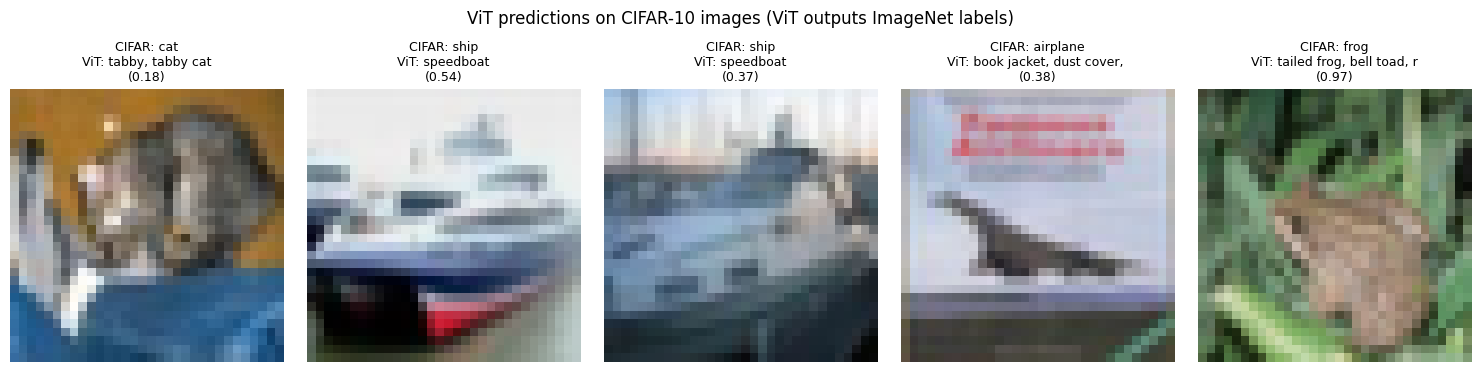

In [16]:
# Exercise 3: ViT inference on CIFAR-10 images

from PIL import Image
import torchvision.transforms.functional as TF

# Load ViT pipeline (downloads ~330 MB on first run)
vit_classifier = pipeline("image-classification", model="google/vit-base-patch16-224")

# Reload val set WITHOUT any transform so we get raw PIL images
raw_val = torchvision.datasets.CIFAR10('./data', train=False, download=False, transform=None)

# Run ViT on the first 5 validation images and compare its ImageNet-label prediction
# to the ground-truth CIFAR-10 label.
print(f"{'idx':<5}{'CIFAR-10 label':<18}{'ViT top prediction':<40}{'Confidence':>10}")
print("-" * 75)

for idx in range(5):
    pil_image, cifar_label = raw_val[idx]
    results = vit_classifier(pil_image)    # pipeline handles 32 to 224 upsampling
    top = results[0]                        # highest-confidence prediction
    print(f"[{idx}]  {CLASSES[cifar_label]:<16}{top['label']:<40}{top['score']:>10.3f}")

# Show the images alongside predictions for visual reference
fig, axes = plt.subplots(1, 5, figsize=(15, 3.5))
for idx, ax in enumerate(axes):
    pil_image, cifar_label = raw_val[idx]
    results = vit_classifier(pil_image)
    top = results[0]
    ax.imshow(pil_image)
    ax.set_title(f"CIFAR: {CLASSES[cifar_label]}\nViT: {top['label'][:25]}\n({top['score']:.2f})",
                 fontsize=9)
    ax.axis('off')
plt.suptitle("ViT predictions on CIFAR-10 images (ViT outputs ImageNet labels)", y=1.05)
plt.tight_layout()
plt.show()


**Exercise 3 Answers:**

1. For each of the 5 images, did ViT's top prediction semantically match the CIFAR-10 label (even if the exact words differ)?
   > **4 out of 5 matched semantically.** The cat came back as `"tabby, tabby cat"` (0.18), both ships as `"speedboat"` (0.54 and 0.37), and the frog as `"tailed frog, bell toad, ribbed toad, tailed toad, Ascaphus trui"` (0.97, comically specific). The airplane was the only miss: ViT predicted `"book jacket, dust cover"` (0.38), probably because the 32x32 image has a red band at the top that resembles a book spine once upsampled to 224x224. Confidence scores are also noticeably lower (0.18 to 0.54 for most) than they'd be on natural-resolution photos, which is another symptom of the extreme upscaling.

2. ViT uses no convolutions, only attention on 16x16 patches. What do you think it "learned" to look for?
   > Because attention lets every patch directly "ask" every other patch about its content, ViT learns **global compositional patterns**: how regions of an image relate to one another. For a car, it's not just detecting wheel-shaped textures locally (which a CNN does well). It's learning that *a round dark region near the bottom-left tends to co-occur with a metallic horizontal surface above it, which tends to co-occur with windows further up*. Visualizations in the original ViT paper show early-layer attention already spanning the full image, which is something a CNN only achieves after many layers of pooling. Essentially: **CNNs build up from parts to wholes; ViT can look at the whole immediately.**

3. ViT was pretrained on 14M images; your fine-tuned ResNet was adapted with only 3,000. Why does scale matter so much for ViT specifically?
   > CNNs come with **built-in inductive biases**: translation invariance (a cat is a cat regardless of where it sits in the frame), local connectivity, and a hierarchical structure that prioritizes nearby pixels. These architectural priors are essentially *free prior knowledge* baked into the model, which lets CNNs learn from smaller datasets. ViT has none of this. It sees patches as an unordered sequence and has to learn spatial structure purely from data, including basic facts like "adjacent patches are related." That's why the original paper showed ViT *underperforming* ResNet when trained only on ImageNet-1k (1.3M images), but *beating* it once scaled to ImageNet-21k or JFT-300M. For a 3,000-image task, ViT fine-tuning from scratch would be a bad idea. You'd have to rely on a pretrained ViT, exactly like we did here by using it for inference.


---
## Part 4 — Reflection

Answer the questions below. These connect today’s experiments back to the lecture and seed your thinking for the final project.

**Q1.** The fine-tuned ResNet converged faster and likely reached higher val accuracy than your scratch CNN, even though ResNet was originally trained on ImageNet (1,000 very different classes). Why does transfer learning work across domains?
> Visual features are **hierarchical and largely domain-agnostic at the lower levels**. The early layers of any CNN trained on natural images (ImageNet, CIFAR, medical scans, satellite photos) end up learning roughly the same things: oriented edges, color contrasts, simple textures, corners. Middle layers learn composite patterns (fur-like textures, wheel-like shapes, window grids). Only the final layers are highly task-specific. Transfer learning exploits this: we keep the 11M ImageNet-trained parameters as a frozen "universal visual vocabulary" and just retrain the classifier head to map those features to CIFAR-10 labels. Our scratch CNN had to learn everything, including those universal edge detectors, from 3,000 examples, which is wildly insufficient. ResNet starts from a position of knowing what an edge *is* before it ever sees CIFAR-10.

**Q2.** You froze 97%+ of ResNet's parameters and only trained the final layer. What is the risk of unfreezing *more* layers when you have limited training data (3,000 images)?
> Two coupled risks: **catastrophic forgetting** and **overfitting**. With a small dataset, gradient updates on millions of previously well-trained parameters push them toward fitting the small, noisy training set, and those updates overwrite useful ImageNet knowledge the model had accumulated across 1.2M images. At the same time, the extra trainable capacity (demonstrated in Exercise 2, going from 5,130 to 8.4M trainable params) means the model has enough flexibility to memorize the 3,000 training images' idiosyncratic features (lighting quirks, backgrounds, artifact patterns) that don't generalize. My actual run confirmed this: unfreezing layer4 drove training accuracy to 80.47% while validation only reached 53.12%, a clear overfitting signature. **Mitigations:** differential learning rates (tiny LR for unfrozen pretrained layers, larger for the new head, which is why Exercise 2 uses 1e-4 vs 1e-3), regularization (dropout, weight decay), and data augmentation. But the cleanest answer with 3K images is: don't unfreeze.

**Q3.** ViT classifies the same images without any convolutions, just attention over 16x16 patches. Convolutional filters detect **local** patterns (edges, textures). What kind of patterns might attention capture that convolutions miss?
> Attention captures **long-range and relational structure**, the kind of information that requires comparing distant parts of an image. A CNN has to stack many layers of pooling to see the whole image; attention does it in a single layer. Concretely, attention can learn things like:
> - **Part-whole relationships**: wheels at the bottom-left + bottom-right + chassis in between = car. A CNN infers this indirectly through spatial hierarchy; attention can compute it explicitly.
> - **Symmetry and spatial correspondence**: two eyes equidistant from a nose; matching left and right sides of a face.
> - **Context-object relationships**: a small animal on water is probably a duck; the same animal on grass is probably a rabbit. Attention lets the background directly inform the foreground prediction.
> - **Scene-level composition**: the layout of a room, not just the objects in it.
>
> The tradeoff is that attention is more data-hungry (see Exercise 3, Q3) because these relational patterns aren't given to the architecture as priors. They have to be learned.

**Q4.** If you were building a production image classifier for a company with only 500 labeled images, which approach would you choose, scratch CNN, fine-tuned ResNet, or ViT? Justify your answer.
> **Fine-tuned ResNet with a frozen backbone.** This is the correct industrial choice and it's not close. My reasoning:
> - **Scratch CNN is out.** 500 images is nowhere near enough to learn useful feature detectors from random initialization. You'd get 20 to 30% accuracy on a 10-class problem, barely above random. The parameter-to-example ratio is catastrophic.
> - **Full ViT fine-tuning is out** for the same reason, amplified: ViT has no inductive biases so it needs even more data than a CNN. A pretrained ViT used only for *inference* could work if the target classes happen to overlap with ImageNet (as Exercise 3 shows), but that's a lucky-domain scenario, not a reliable product strategy.
> - **Fine-tuned ResNet (frozen backbone + new head)** gives the best data-efficiency-to-accuracy ratio. With 500 images and only ~5K trainable parameters (the new `fc` layer), the ratio is healthy (~100 examples per parameter). The pretrained ImageNet features do the heavy lifting.
>
> **Practical additions I'd push for in production:** heavy data augmentation (horizontal flips, rotations, color jitter, mixup, so each image effectively becomes many), cross-validation instead of a single train/val split (500 images is too small to waste), a pretrained EfficientNet or ConvNeXt backbone (often beats ResNet with similar compute), and active learning to prioritize labeling the most uncertain examples. If the domain is very different from ImageNet (medical imaging, satellite, industrial defects), I'd also consider a domain-specific pretrained backbone. Medical ImageNet equivalents like RadImageNet exist.


---
## Bonus — Visualize CNN Feature Maps

After training `SimpleCNN`, you can extract the **intermediate activations** — what each filter “sees” — by passing an image through just the first Conv2d layer.

The first layer has 16 filters (feature maps). Each filter learns to respond to a different low-level pattern: edges, color gradients, corners, etc.

True label: cat
Feature maps shape: torch.Size([1, 16, 32, 32])  =>  16 filters, each 32x32


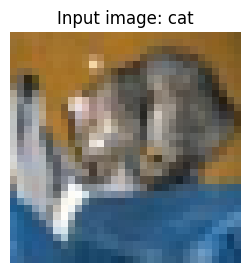

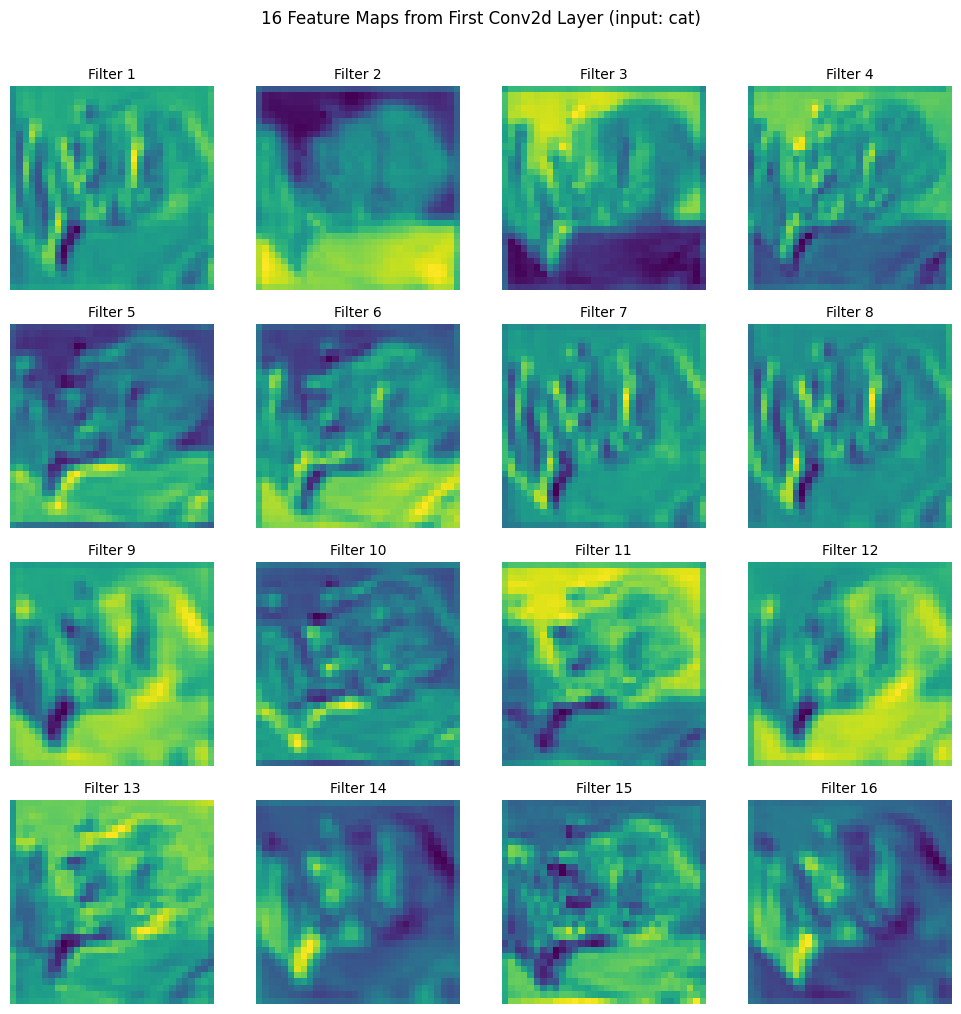

In [17]:
# Bonus: Visualize all 16 feature maps from the first Conv2d layer

scratch_model.eval()

# Take the first validation image
sample_image, sample_label = val_subset[0]
print(f"True label: {CLASSES[sample_label]}")

# Add a batch dimension: (C, H, W) -> (1, C, H, W)
x = sample_image.unsqueeze(0).to(device)

# 1. Forward pass through the first Conv2d layer only
with torch.no_grad():
    feature_maps = scratch_model.features[0](x)   # shape: (1, 16, 32, 32)

print(f"Feature maps shape: {feature_maps.shape}  =>  16 filters, each 32x32")

# Also show the original input image for visual reference
input_img = sample_image.permute(1, 2, 0).cpu().numpy() * 0.5 + 0.5   # denormalize
plt.figure(figsize=(3, 3))
plt.imshow(input_img.clip(0, 1))
plt.title(f"Input image: {CLASSES[sample_label]}")
plt.axis('off')
plt.show()

# 2. Plot all 16 feature maps as a 4x4 grid
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
for i, ax in enumerate(axes.flat):
    fm = feature_maps[0, i].cpu().numpy()
    # Per-filter min/max normalization so low-contrast filters stay visible
    fm_norm = (fm - fm.min()) / (fm.max() - fm.min() + 1e-8)
    ax.imshow(fm_norm, cmap='viridis')
    ax.set_title(f"Filter {i+1}", fontsize=10)
    ax.axis('off')
plt.suptitle(f"16 Feature Maps from First Conv2d Layer (input: {CLASSES[sample_label]})",
             y=1.01, fontsize=12)
plt.tight_layout()
plt.show()


**Bonus Observations:**

Describe what patterns you see in the 16 feature maps. Are some filters detecting horizontal edges? Vertical edges? Color blobs? High-frequency noise?

> Looking at the 16 feature maps from the first Conv2d layer (input: cat), I can roughly group the filters into a few behaviors:
>
> - **Edge detectors** (the majority, about 6 to 8 filters, including filters 1, 7, 9, and 11): clear activation along horizontal, vertical, and diagonal boundaries. Filter 1 in particular lights up along the cat's fur edges and the blanket fold, looking very much like a classical Sobel edge response. These are the Sobel-like edge detectors that emerge in any CNN's first layer, one of the earliest and most reproducible findings in deep learning (Zeiler & Fergus 2013, and earlier).
> - **Color and intensity blobs** (filters 3, 4, 6, 10): broad low-frequency activations that track large regions. Filter 3 shows bright activation in the orange-background area; filter 6 looks like it's responding to the dark/shadow regions. These filters respond to dominant color channels rather than fine structure.
> - **High-contrast corner and texture detectors** (filters 5, 8, 12): more localized activations that light up where multiple edges meet. These seem to be catching the boundary between the cat's body and the blue blanket.
> - **Near-dead or low-contrast filters** (filters 2 and 16): maps that are mostly uniform. With only 3,000 training images and 2 training epochs (CPU run), some filters haven't differentiated far from their random initialization yet. With more epochs or more data, they'd likely specialize further.
>
> **Takeaway:** even this tiny 2-block CNN trained on 3K images for just 2 epochs spontaneously rediscovers the edge, color, and corner detector hierarchy that was designed by hand in classical computer vision (think Canny edge detection, Harris corners, SIFT). That's the core promise of representation learning, and the reason transfer learning works across domains: these primitive features are universal.


---
## Looking Ahead — W5

Next week we go inside the Transformer — the architecture behind every modern LLM.
You’ll visualize real attention weights in BERT and generate text with GPT-2.

**Before W5:**
- [ ] All exercises in this notebook completed and cells run top-to-bottom without errors
- [ ] Optional: read ["An Image is Worth 16x16 Words"](https://arxiv.org/abs/2010.11929) — the original ViT paper (skim the intro + Figure 1)
- [ ] Optional: explore `torchvision.models` to see the full list of available pretrained architectures

**Questions to sit with:**
- ResNet18 has 18 layers; ResNet152 has 152. Why not always use the deepest model?
- Freezing layers speeds up training. But what information are you *not* allowing the model to learn?
- ViT treats image patches like words in a sentence. What does that tell you about the relationship between vision and language models?